# Base learner standard deviation maps



## 1. Initialize libraries and Earth Engine

In [1]:
# Import the libraries used for Earth Engine access, image download, and plotting.
import ee
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
from matplotlib.patches import Rectangle

# Initialize the Earth Engine session.
ee.Initialize()

## 2. Load assets and prepare shared objects

In [2]:
# Load the five base learner prediction rasters from Earth Engine assets.
knn = ee.Image('projects/ee-islamkm/assets/baselearner_knn_mngrv')
logreg = ee.Image('projects/ee-islamkm/assets/baselearner_logreg_mngrv')
rf = ee.Image('projects/ee-islamkm/assets/baselearner_rf_mngrv')
svc = ee.Image('projects/ee-islamkm/assets/baselearner_svc_mgrv')
xgb = ee.Image('projects/ee-islamkm/assets/baselearner_xgb_mgrv')

# Combine the base learner rasters into one multiband image.
combined = ee.Image.cat([knn, logreg, rf, svc, xgb])

# Compute the standard deviation across learners to represent disagreement.
std_dev_map = combined.reduce(ee.Reducer.stdDev()).rename('baselearner_stdDev')

# Load the two point collections used in the figure.
fc1_cert = ee.FeatureCollection('projects/ee-islamkm/assets/interpreter1_200pts_certain')
fc1_conf = ee.FeatureCollection('projects/ee-islamkm/assets/interpreter1_200pts')

# Build a bounding region that covers both point collections.
region = fc1_cert.geometry().bounds().union(fc1_conf.geometry().bounds(), maxError=1)

# Define the shared color palette used in the map thumbnails and colorbars.
viridis_palette = [
    '#440154', '#482878', '#3e4989', '#31688e', '#26828e',
    '#1f9e89', '#35b779', '#6ece58', '#b5de2b', '#fde724'
]

# Create a matching matplotlib colormap for the custom Earth Engine palette.
viridis_cmap = mcolors.LinearSegmentedColormap.from_list('viridis_custom', viridis_palette)

## 3. Helper functions

In [3]:
# Extract coordinates from a FeatureCollection that contains Point or MultiPoint geometries.
def get_coordinates_from_multipoint(fc):
    """Extract coordinates from a FeatureCollection containing Point or MultiPoint geometries."""
    coords = []
    features = fc.getInfo()['features']

    for feature in features:
        geom = feature['geometry']
        if geom['type'] == 'MultiPoint':
            coords.extend(geom['coordinates'])
        elif geom['type'] == 'Point':
            coords.append(geom['coordinates'])

    return coords


# Split a coordinate list into separate longitude and latitude lists.
def split_lon_lat(coords):
    """Return separate longitude and latitude lists from coordinate pairs."""
    lons = [coord[0] for coord in coords]
    lats = [coord[1] for coord in coords]
    return lons, lats


# Download an Earth Engine thumbnail as a PIL image.
def get_ee_thumbnail(image, region_geometry, dimensions, vis_params):
    """Fetch an Earth Engine thumbnail and return it as a PIL image."""
    url = image.getThumbURL({
        'region': region_geometry,
        'dimensions': dimensions,
        'format': 'png',
        **vis_params
    })
    response = requests.get(url)
    response.raise_for_status()
    return Image.open(BytesIO(response.content))


# Get bounding box limits from an Earth Engine geometry.
def get_bbox_limits(geometry):
    """Return min/max longitude and latitude from a geometry bounding box."""
    bbox = geometry.bounds().getInfo()['coordinates'][0]
    min_lon = min(coord[0] for coord in bbox)
    max_lon = max(coord[0] for coord in bbox)
    min_lat = min(coord[1] for coord in bbox)
    max_lat = max(coord[1] for coord in bbox)
    return min_lon, max_lon, min_lat, max_lat


# Expand a plotting extent by a given fraction.
def extend_limits(min_lon, max_lon, min_lat, max_lat, extend_factor):
    """Expand longitude and latitude limits by a fixed fraction."""
    lon_range = max_lon - min_lon
    lat_range = max_lat - min_lat

    xlim_min = min_lon - lon_range * extend_factor
    xlim_max = max_lon + lon_range * extend_factor
    ylim_min = min_lat - lat_range * extend_factor
    ylim_max = max_lat + lat_range * extend_factor

    return xlim_min, xlim_max, ylim_min, ylim_max


# Get the longitude and latitude extent of a zoom region.
def get_zoom_extent(zoom_region):
    """Return the plotting extent for a zoom box."""
    return [
        zoom_region['lon_center'] - zoom_region['size'] / 2,
        zoom_region['lon_center'] + zoom_region['size'] / 2,
        zoom_region['lat_center'] - zoom_region['size'] / 2,
        zoom_region['lat_center'] + zoom_region['size'] / 2
    ]


# Download a zoomed Earth Engine thumbnail centered on a given location.
def get_zoom_image(std_dev_map, lon_center, lat_center, size, vis_params):
    """Fetch a zoomed thumbnail around a given center point."""
    zoom_bbox = ee.Geometry.Rectangle([
        lon_center - size / 4,
        lat_center - size / 4,
        lon_center + size / 4,
        lat_center + size / 4
    ])

    return get_ee_thumbnail(
        image=std_dev_map,
        region_geometry=zoom_bbox,
        dimensions=512,
        vis_params=vis_params
    )


# Filter coordinate pairs to the ones that fall inside a plotting extent.
def filter_points_in_extent(lons, lats, extent):
    """Return longitude and latitude values that fall inside the extent."""
    filtered_lons = []
    filtered_lats = []

    for lon, lat in zip(lons, lats):
        if extent[0] <= lon <= extent[1] and extent[2] <= lat <= extent[3]:
            filtered_lons.append(lon)
            filtered_lats.append(lat)

    return filtered_lons, filtered_lats

## 4. Prepare point coordinates

In [4]:
# Extract coordinates from the two point collections.
cert_coords = get_coordinates_from_multipoint(fc1_cert)
conf_coords = get_coordinates_from_multipoint(fc1_conf)

# Separate each coordinate collection into longitude and latitude lists.
cert_lons, cert_lats = split_lon_lat(cert_coords)
conf_lons, conf_lats = split_lon_lat(conf_coords)

# Compute the plotting bounds for the full study area.
min_lon, max_lon, min_lat, max_lat = get_bbox_limits(region)

## 5. Finalized map

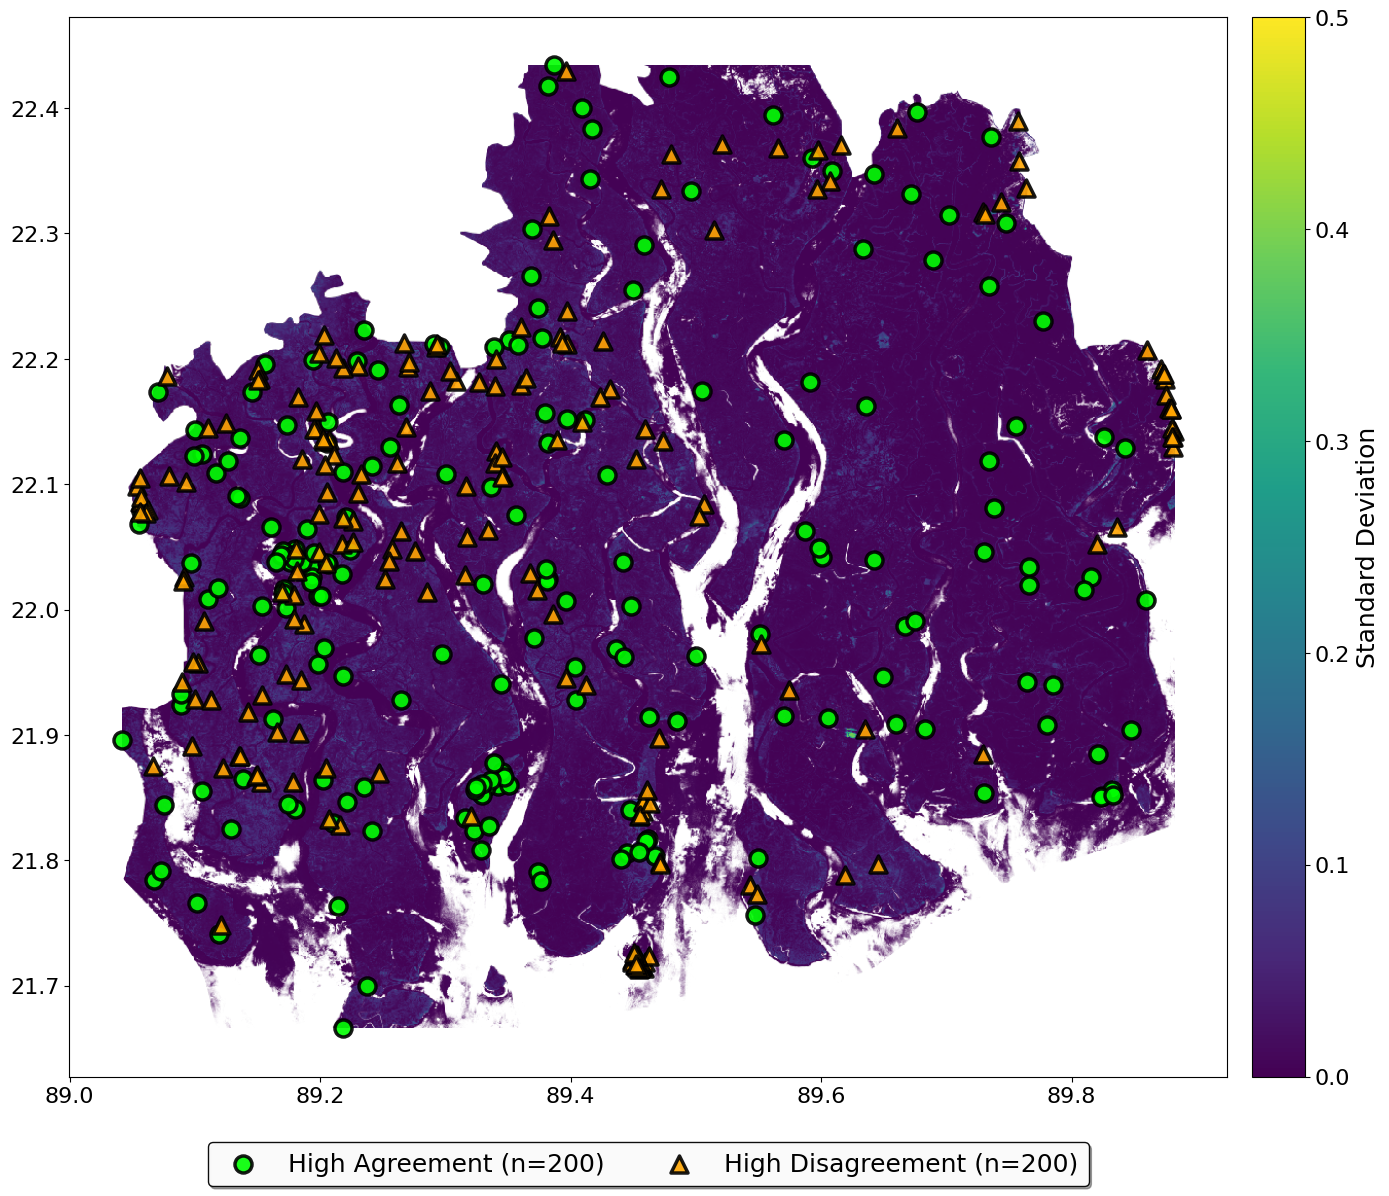

In [5]:
# Define visualization settings for the full standard deviation map.
vis_params_main = {
    'min': 0,
    'max': 0.5,
    'palette': viridis_palette
}

# Download the full map thumbnail from Earth Engine.
img = get_ee_thumbnail(
    image=std_dev_map,
    region_geometry=region,
    dimensions=1024,
    vis_params=vis_params_main
)

# Expand the displayed extent slightly beyond the asset bounds.
xlim_min, xlim_max, ylim_min, ylim_max = extend_limits(
    min_lon=min_lon,
    max_lon=max_lon,
    min_lat=min_lat,
    max_lat=max_lat,
    extend_factor=0.05
)

# Create the figure and axis for the final map.
fig, ax = plt.subplots(figsize=(14, 12))

# Draw the standard deviation map.
ax.imshow(img, extent=[min_lon, max_lon, min_lat, max_lat], aspect='auto')

# Apply the expanded map limits.
ax.set_xlim(xlim_min, xlim_max)
ax.set_ylim(ylim_min, ylim_max)

# Overlay high-agreement sample points.
ax.scatter(
    cert_lons,
    cert_lats,
    c='lime',
    s=150,
    marker='o',
    edgecolors='black',
    linewidths=2.5,
    alpha=0.9,
    label=f'High Agreement (n={len(cert_lons)})',
    zorder=6
)

# Overlay high-disagreement sample points.
ax.scatter(
    conf_lons,
    conf_lats,
    c='orange',
    s=150,
    marker='^',
    edgecolors='black',
    linewidths=2.5,
    alpha=0.9,
    label=f'High Disagreement (n={len(conf_lons)})',
    zorder=6
)

# Keep the axis labels blank but retain the original formatting intent.
ax.set_xlabel('', fontsize=20, fontweight='bold')
ax.set_ylabel('', fontsize=20, fontweight='bold')

# Format tick labels.
ax.tick_params(axis='both', which='major', labelsize=16)

# Add the legend below the map.
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    fontsize=18,
    framealpha=0.95,
    edgecolor='black',
    fancybox=True,
    shadow=True,
    ncol=2
)

# Add the colorbar for standard deviation values.
sm = plt.cm.ScalarMappable(cmap=viridis_cmap, norm=plt.Normalize(vmin=0, vmax=0.5))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, fraction=0.046)
cbar.set_label('Standard Deviation', fontsize=18)
cbar.ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()

## 6. Zoomed-in panel

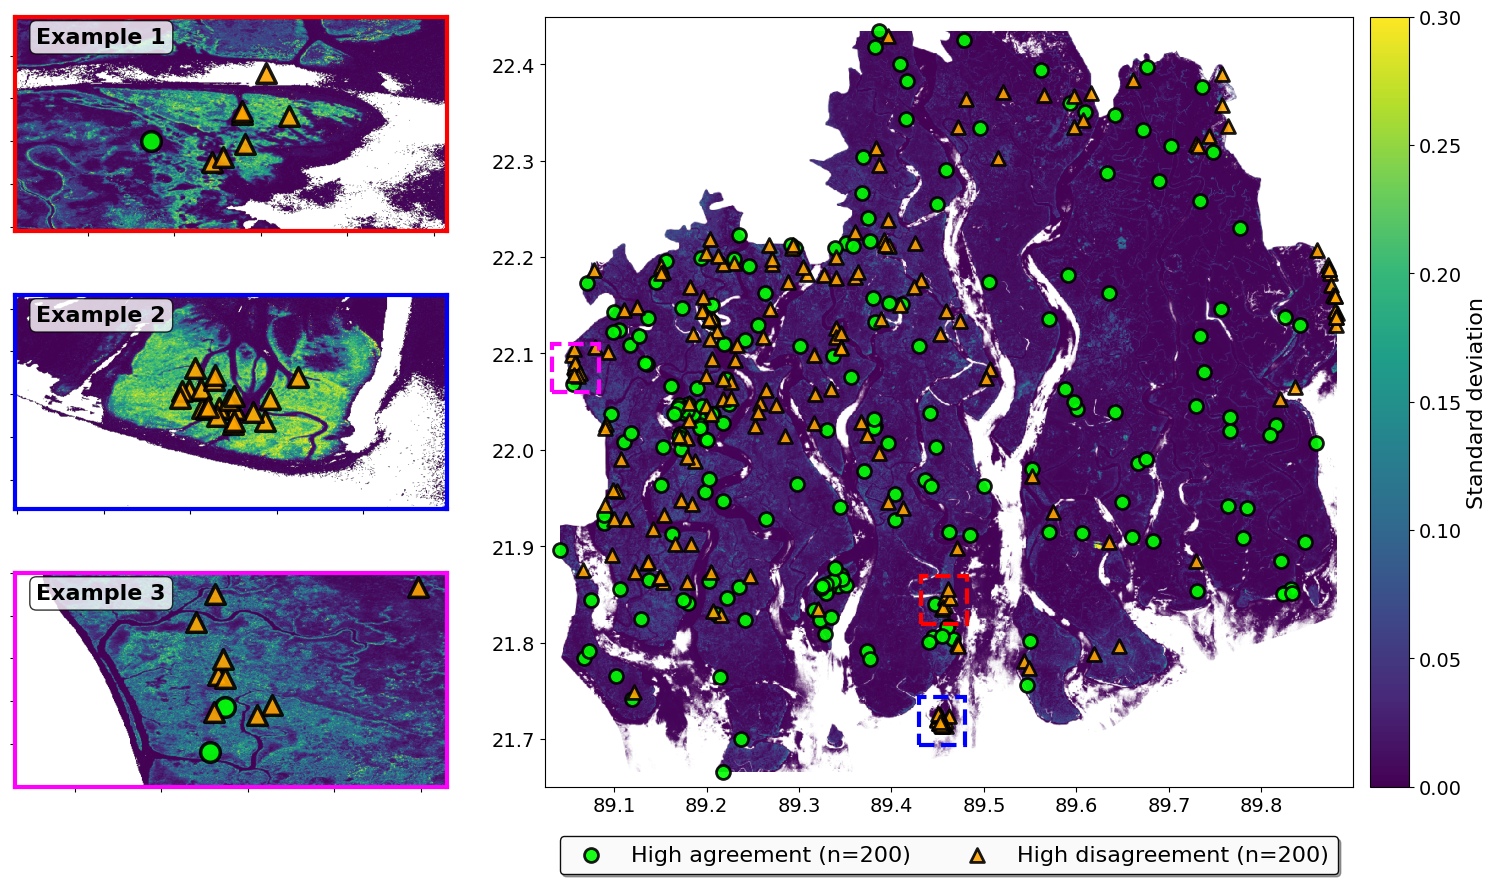

In [6]:
# Define visualization settings for the zoom-panel version of the map.
vis_params_zoom = {
    'min': 0.0,
    'max': 0.3,
    'palette': viridis_palette
}

# Download the full map thumbnail used in the right-side main panel.
img = get_ee_thumbnail(
    image=std_dev_map,
    region_geometry=region,
    dimensions=1024,
    vis_params=vis_params_zoom
)

# Expand the displayed extent slightly for the zoom-panel layout.
xlim_min, xlim_max, ylim_min, ylim_max = extend_limits(
    min_lon=min_lon,
    max_lon=max_lon,
    min_lat=min_lat,
    max_lat=max_lat,
    extend_factor=0.02
)

# Define the three manually selected zoom regions.
zoom_size = 0.05
zoom_regions = [
    {'lon_center': 89.4566, 'lat_center': 21.8441, 'size': zoom_size},
    {'lon_center': 89.45474, 'lat_center': 21.71827, 'size': zoom_size},
    {'lon_center': 89.0581, 'lat_center': 22.08504, 'size': zoom_size}
]

# Download the three zoomed thumbnails.
zoom_images = [
    get_zoom_image(std_dev_map, zr['lon_center'], zr['lat_center'], zr['size'], vis_params_zoom)
    for zr in zoom_regions
]

# Create the multi-panel figure layout.
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 2, width_ratios=[1, 2], hspace=0.3, wspace=0.15)

# Create one axis for each zoom panel and one for the main map.
ax_zoom1 = fig.add_subplot(gs[0, 0])
ax_zoom2 = fig.add_subplot(gs[1, 0])
ax_zoom3 = fig.add_subplot(gs[2, 0])
ax_main = fig.add_subplot(gs[:, 1])
zoom_axes = [ax_zoom1, ax_zoom2, ax_zoom3]

# Draw the main map.
ax_main.imshow(img, extent=[min_lon, max_lon, min_lat, max_lat], aspect='auto')
ax_main.set_xlim(xlim_min, xlim_max)
ax_main.set_ylim(ylim_min, ylim_max)

# Overlay all sample points on the main map.
ax_main.scatter(
    cert_lons,
    cert_lats,
    c='lime',
    s=100,
    marker='o',
    edgecolors='black',
    linewidths=2,
    alpha=0.9,
    label=f'High agreement (n={len(cert_lons)})',
    zorder=6
)
ax_main.scatter(
    conf_lons,
    conf_lats,
    c='orange',
    s=100,
    marker='^',
    edgecolors='black',
    linewidths=2,
    alpha=0.9,
    label=f'High disagreement (n={len(conf_lons)})',
    zorder=6
)

# Draw rectangles on the main map to show the zoom-window locations.
colors_rect = ['red', 'blue', 'magenta']
for i, zr in enumerate(zoom_regions):
    rect = Rectangle(
        (zr['lon_center'] - zr['size'] / 2, zr['lat_center'] - zr['size'] / 2),
        zr['size'],
        zr['size'],
        linewidth=3,
        edgecolor=colors_rect[i],
        facecolor='none',
        linestyle='--',
        zorder=7
    )
    ax_main.add_patch(rect)

# Format the main map ticks and legend.
ax_main.tick_params(axis='both', which='major', labelsize=14)
ax_main.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    fontsize=16,
    framealpha=0.95,
    edgecolor='black',
    fancybox=True,
    shadow=True,
    ncol=2
)

# Add the main map colorbar.
sm = plt.cm.ScalarMappable(cmap=viridis_cmap, norm=plt.Normalize(vmin=0, vmax=0.3))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax_main, orientation='vertical', pad=0.02, fraction=0.046)
cbar.set_label('Standard deviation', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Draw the three zoom panels.
for i, (ax, zr, zoom_img) in enumerate(zip(zoom_axes, zoom_regions, zoom_images)):
    # Compute the plotted extent for this zoom panel.
    extent = get_zoom_extent(zr)

    # Show the zoomed standard deviation image.
    ax.imshow(zoom_img, extent=extent, aspect='auto')

    # Subset the sample points to those inside the zoom window.
    cert_in_zoom_lons, cert_in_zoom_lats = filter_points_in_extent(cert_lons, cert_lats, extent)
    conf_in_zoom_lons, conf_in_zoom_lats = filter_points_in_extent(conf_lons, conf_lats, extent)

    # Overlay the points inside the zoom window.
    ax.scatter(
        cert_in_zoom_lons,
        cert_in_zoom_lats,
        c='lime',
        s=200,
        marker='o',
        edgecolors='black',
        linewidths=2.5,
        alpha=0.9,
        zorder=6
    )
    ax.scatter(
        conf_in_zoom_lons,
        conf_in_zoom_lats,
        c='orange',
        s=200,
        marker='^',
        edgecolors='black',
        linewidths=2.5,
        alpha=0.9,
        zorder=6
    )

    # Set the zoomed extent and suppress tick labels.
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Match the panel border color to the rectangle shown on the main map.
    for spine in ax.spines.values():
        spine.set_edgecolor(colors_rect[i])
        spine.set_linewidth(3)

    # Add the example label to each zoom panel.
    ax.text(
        0.05,
        0.95,
        f'Example {i + 1}',
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

# Save the figure to disk using the original output path.
# plt.savefig(r'D:\Research\uncertainty_paper\sd_baselearners.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Figure caption

**Figure X.** Spatial distribution of base learner agreement in mangrove classification. Standard deviation of predictions from five base learners (KNN, LogisticRegression, RandomForest, SVC, XGBoost) across the study area, where higher values (yellow) indicate greater model disagreement. Green circles and orange triangles represent stratified sample points (n = 200 each) selected from high- and low-agreement areas, respectively, which were subsequently interpreted by three independent interpreters blinded to model outputs and standard deviation values. Three zoomed examples show detailed spatial patterns of agreement and disagreement. White areas are masked non-mangrove regions.